In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from Crypto.Util.number import *
from matplotlib import ticker
import seaborn as sns

In [2]:
L = 4
N = 10000
length = 40000
profile_trace = np.zeros((4*N,length))

Profiling traces

In [3]:
profile_trace[0:N] = np.load('../Dataset/profiling_40000traces_set1.npy')
profile_trace[N:2*N] = np.load('../Dataset/profiling_40000traces_set2.npy')
profile_trace[2*N:3*N] = np.load('../Dataset/profiling_40000traces_set3.npy')
profile_trace[3*N:4*N] = np.load('../Dataset/profiling_40000traces_set4.npy')

In [39]:
profile_u = np.zeros((4*N,L,256))
profile_u = np.load('../Dataset/profiling_40000_u=cs.npy')

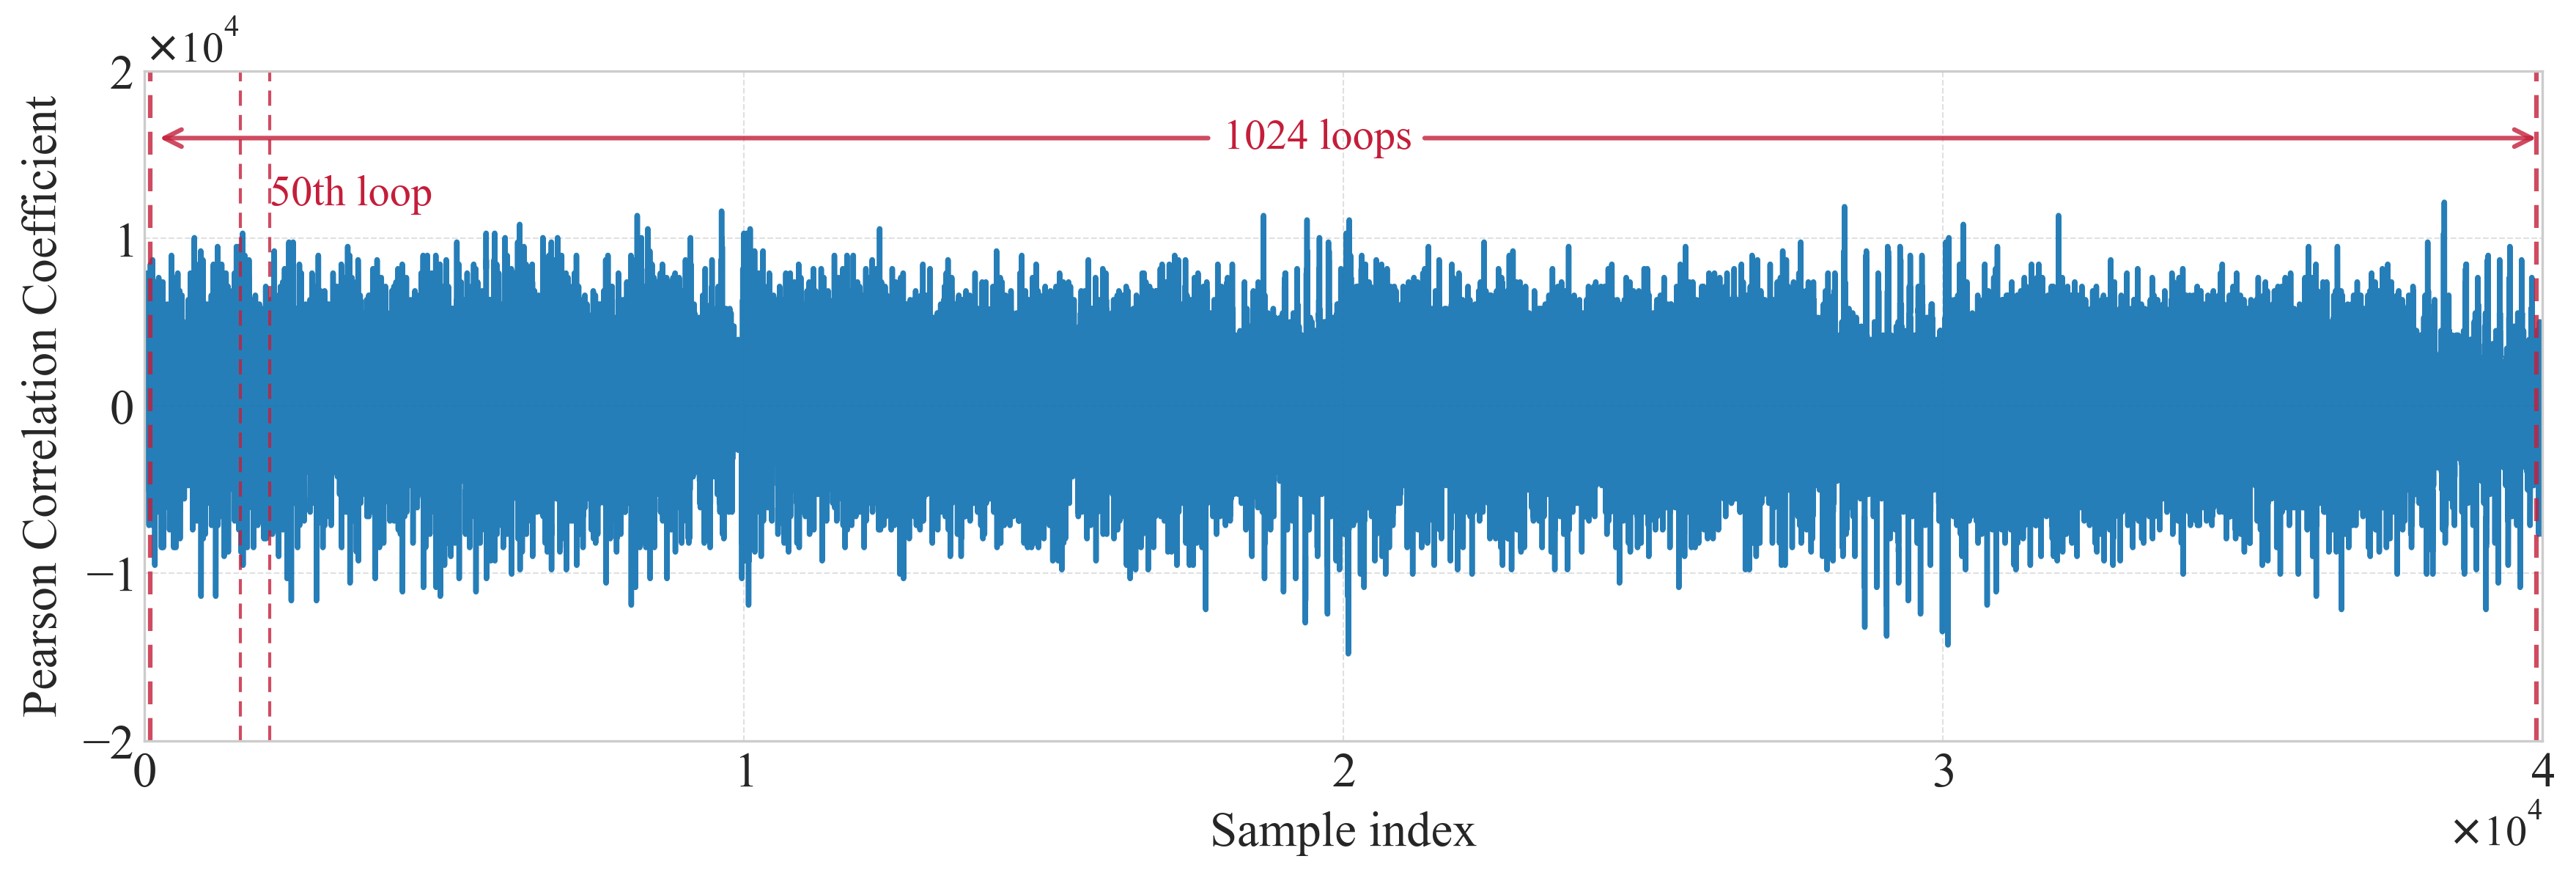

In [127]:
# Set global style parameters

font_size = 16
rho = np.load('rho.npy')

x = [i for i in range(length)]
plt.style.use('seaborn-whitegrid')  # 使用学术风格网格
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size-4,
    'lines.linewidth': 1.2,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5
})

# Create figure with adjusted dimensions (保持宽高比兼顾可读性)
plt.figure(figsize=(12, 4.5), dpi=300)


line = plt.plot(x, profile_trace[0], 
                color='#1A77B4',  # 色觉障碍友好色系
                linewidth=1.8,
                alpha=0.95,
                solid_capstyle='round',
                label=r'$\mathcal{T}_{power}$')  # LaTeX数学符号标注
    
# 坐标轴优化
ax = plt.gca()

ax.axvline(x=100, color='#C41E3A', linestyle='--', 
          linewidth=1.5, alpha=0.8, dashes=(5, 3))
ax.axvline(x=39900, color='#C41E3A', linestyle='--', 
          linewidth=1.5, alpha=0.8, dashes=(5, 3))

# 添加带箭头的标注（替换原本文本）
ax.annotate('1024 loops', 
            xy=(40000, 1.6e4),       # 箭头终点（坐标中间点）
            xytext=(18000, 1.6e4),   # 文本起始位置
            arrowprops=dict(
                arrowstyle='->',      # 箭头样式
                color='#C41E3A',      # 保持色系一致
                lw=1.5,              # 线宽与虚线匹配
                alpha=0.8           # 透明度统一
            ),
            ha='left',               # 文本左对齐
            va='center',             # 垂直居中
            color='#C41E3A',         # 文本颜色
            fontsize=14)
ax.annotate('', 
            xy=(0, 1.6e4),         # 箭头指向x=0坐标线
            xytext=(18000, 1.6e4),  # 文本显示在右侧5k位置
            arrowprops=dict(
                arrowstyle='->', 
                color='#C41E3A',
                lw=1.5,
                alpha=0.8,
                shrinkA=5,        # 箭头头部缩进
                shrinkB=5         # 箭头尾部缩进
            ),
            ha='right',          # 文本右对齐
            va='center',
            color='#C41E3A',
            fontsize=14)

ax.axvline(x=1600, color='#C41E3A', linestyle='--', linewidth=1, alpha=0.8, dashes=(5, 3))
ax.axvline(x=2100, color='#C41E3A', linestyle='--', linewidth=1, alpha=0.8, dashes=(5, 3))

plt.text(2100,1.2e4,'50th loop', color='#C41E3A',fontsize=14)

# Create scientific notation formatter for both axes
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0,0))  # Force scientific notation regardless of exponent

ax.xaxis.set_major_formatter(formatter)
ax.xaxis.get_offset_text().set_fontsize(font_size-2)
ax.xaxis.get_offset_text().set_fontfamily('Times New Roman')
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.get_offset_text().set_fontsize(font_size-2)
ax.yaxis.get_offset_text().set_fontfamily('Times New Roman')

# 设置合理的坐标范围
plt.xlim(left=0, right=40000)
plt.ylim(bottom=-0.1, top=1.1)

# 刻度密度优化
plt.xticks(np.arange(0, 40001, 10000))
ax.set_yticks(np.arange(-2e4, 2.1e4, 1e4))

# 添加辅助网格
ax.grid(True, which='major', linestyle='--', alpha=0.6)

# 轴标签优化
plt.xlabel('Sample index', labelpad=5)
plt.ylabel('Pearson Correlation Coefficient', labelpad=5)


# 调整布局和边距
plt.tight_layout(rect=[0, 0, 1, 0.95])  # 为顶部图例留出空间

# 保存为高分辨率矢量图
plt.savefig('Power_Trace.pdf', 
           bbox_inches='tight', 
           pad_inches=0.1,
           dpi=600,
           format='pdf')

Profiling u=cs1

In [5]:
profile_u = np.zeros((4*N,L,256))
profile_u = np.load('../Dataset/profiling_40000_u=cs.npy')

Pearson correlation coefficient between power traces and u

In [57]:
def swar (i):
    i = i & 0xffffffff
    i = i - ((i >> 1) & 0x55555555);
    i = (i & 0x33333333) + ((i >> 2) & 0x33333333);
    i = (i + (i >> 4)) & 0x0f0f0f0f;
    i = i + (i >> 8);
    i = i + (i >> 16);
    return i & 0x3f;

In [ ]:
#13min
length = 40000
rho = np.zeros((L*5,40000))

for j1 in range(L):
    for j2 in range(50,255,50):

        u_hm = np.zeros((length))
        for i in range(length):
            u_hm[i] = swar(profile_u[i][j1][j2])
    
        for i in range(length):
            rho[j1*5+(j2//50-1)][i] = np.abs(np.corrcoef(u_hm,profile_trace.T[i])[0][1])
print(np.max(rho))
np.save('rho.npy',rho)

Pearson Correlation Coefficient

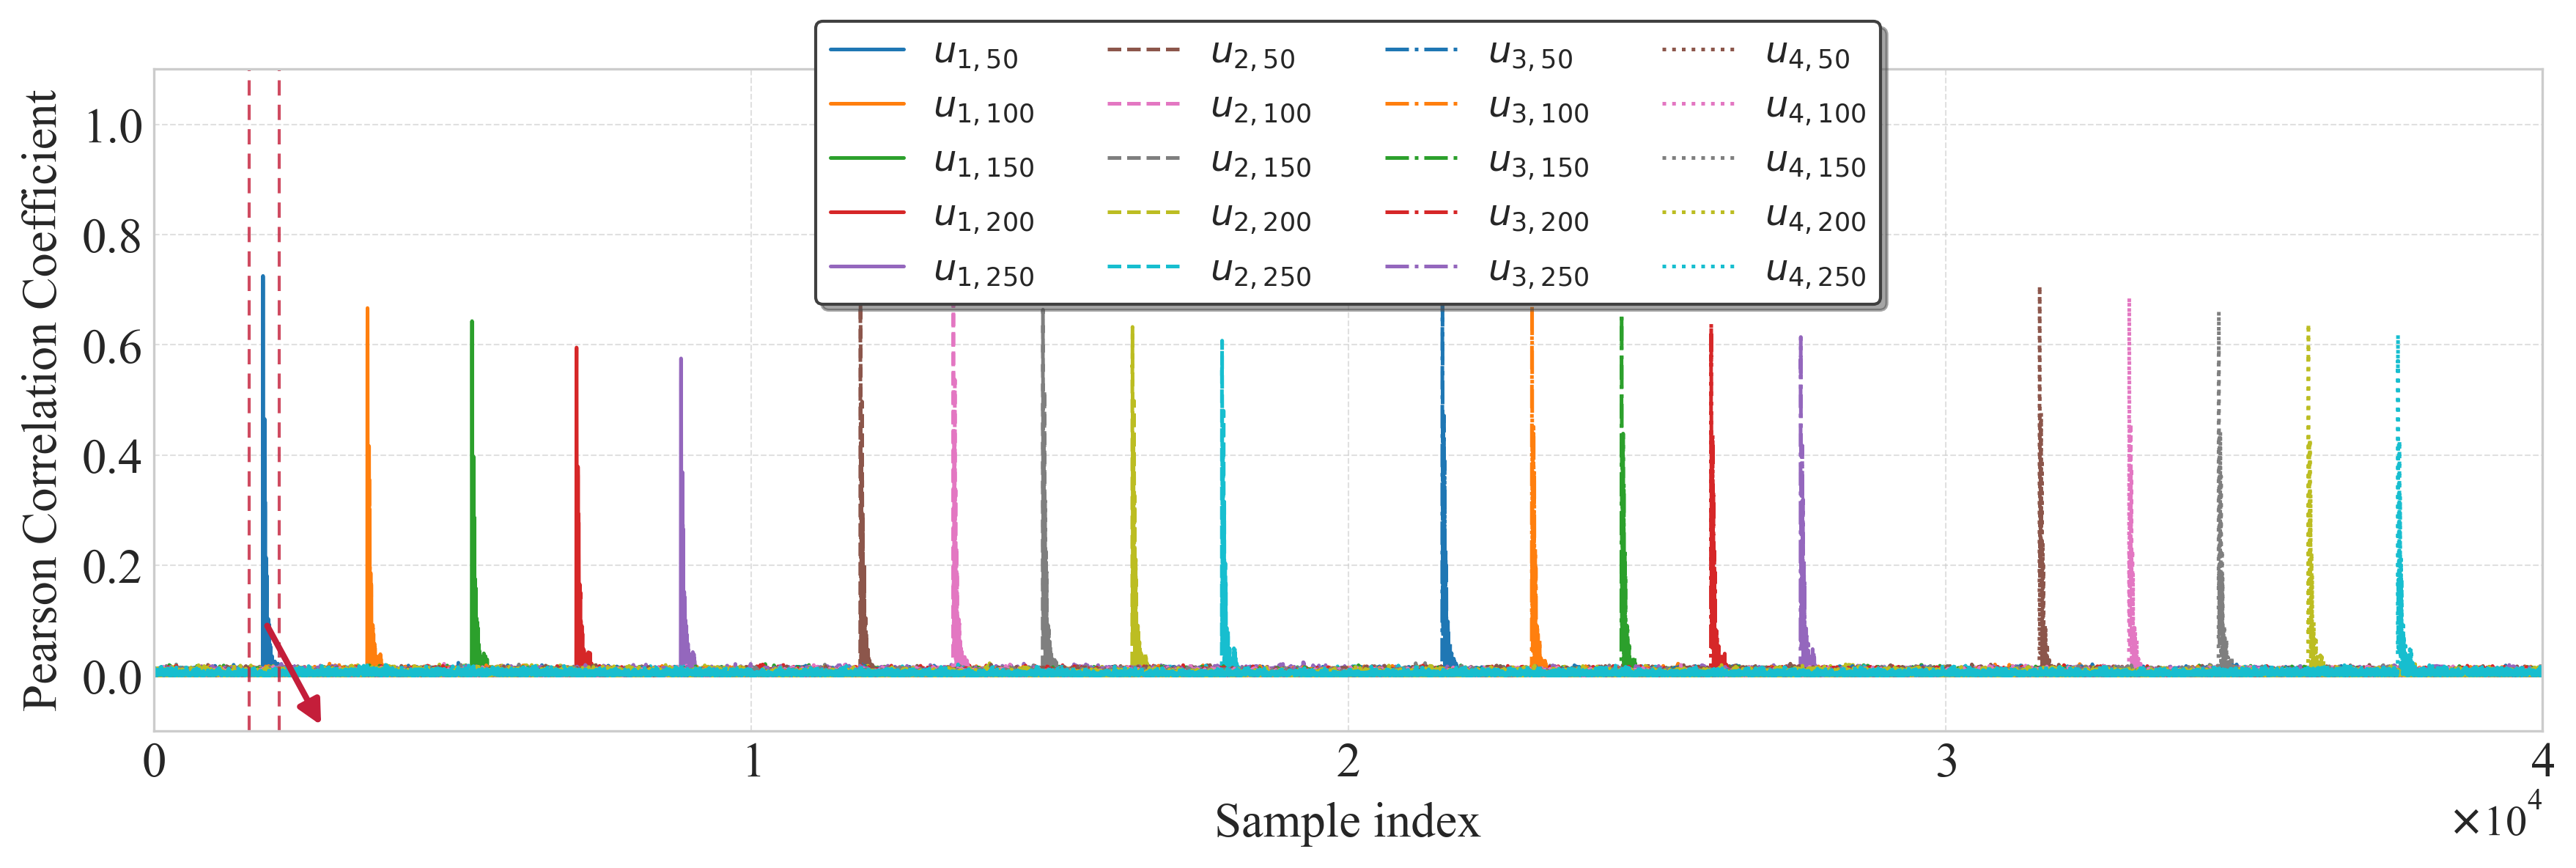

In [128]:
# Set global style parameters

rho = np.load('rho.npy')
font_size = 16
x = [i for i in range(length)]
plt.style.use('seaborn-whitegrid')  # 使用学术风格网格
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size-4,
    'lines.linewidth': 1.2,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5
})

# Create figure with adjusted dimensions (保持宽高比兼顾可读性)
plt.figure(figsize=(12, 4.5), dpi=300)

# 使用更专业的颜色循环
cmap = plt.get_cmap('tab10')
colors = [cmap(i%10) for i in range(len(rho))]
line_styles = ['-', '--', '-.', ':']*2  # 组合线型增强区分度

# 优化绘图循环
for i, trace in enumerate(rho):
    plt.plot(x, trace, 
            color=colors[i],
            linestyle=line_styles[i//5],  # 每5条线更换线型
            label=fr'$u_{{{i//5+1},{(i%5+1)*50}}}$')
    
# 坐标轴优化
ax = plt.gca()

ax.axvline(x=1600, color='#C41E3A', linestyle='--', linewidth=1, alpha=0.8, dashes=(5, 3))
ax.axvline(x=2100, color='#C41E3A', linestyle='--', linewidth=1, alpha=0.8, dashes=(5, 3))

x_start = (1600 + 2100) / 2  # 两条线的中点x位置
y_start = 0.1                # y轴中间位置，可以修改
x_end = x_start + 1000        # 指向较右侧
y_end = y_start - 0.2       # 指向略向下，下移

# 添加箭头注释
ax.annotate('', 
            xy=(x_end, y_end),     # 终点
            xytext=(x_start, y_start),  # 起点
            arrowprops=dict(arrowstyle='-|>', color='#C41E3A', linewidth=2))

# Create scientific notation formatter for both axes
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0,0))  # Force scientific notation regardless of exponent

ax.xaxis.set_major_formatter(formatter)
ax.xaxis.get_offset_text().set_fontsize(font_size-2)
ax.xaxis.get_offset_text().set_fontfamily('Times New Roman')

# 设置合理的坐标范围
plt.xlim(left=0, right=40000)
plt.ylim(bottom=-0.1, top=1.1)

# 刻度密度优化
plt.xticks(np.arange(0, 40001, 10000))
plt.yticks(np.arange(0, 1.1, 0.2))

# 添加辅助网格
ax.grid(True, which='major', linestyle='--', alpha=0.6)

# 轴标签优化
plt.xlabel('Sample index', labelpad=5)
plt.ylabel('Pearson Correlation Coefficient', labelpad=5)

# 图例优化（采用自适应布局）
legend = plt.legend(ncol=4, 
                  loc='upper center',
                  bbox_to_anchor=(0.5, 1.1),
                  prop={'family':'Times New Roman', 'size':font_size-4},
                  frameon=True, 
                  shadow=True)

# 调整布局和边距
plt.tight_layout(rect=[0, 0, 1, 0.95])  # 为顶部图例留出空间

# 保存为高分辨率矢量图
plt.savefig('Correlation Coefficient.pdf', 
           bbox_inches='tight', 
           pad_inches=0.1,
           dpi=600,
           format='pdf')

50th loop

In [59]:
loc = 50
test = 100
lang = 50
tar = [15,16,17]
point = np.zeros((len(tar),test,lang))
point_sum = np.zeros((len(tar),lang))
point_mean = np.zeros((len(tar),lang))
for i in range(len(tar)):
    k = 0
    for j in range(N):
        if swar(profile_u[j][0][50]) == tar[i]:
            point[i][k] =  profile_trace[j][1950:2000]
            point_sum[i] +=  profile_trace[j][1950:2000]
            k += 1
        if k == test:
            break
point_mean = point_sum / test

Comparison of local power traces

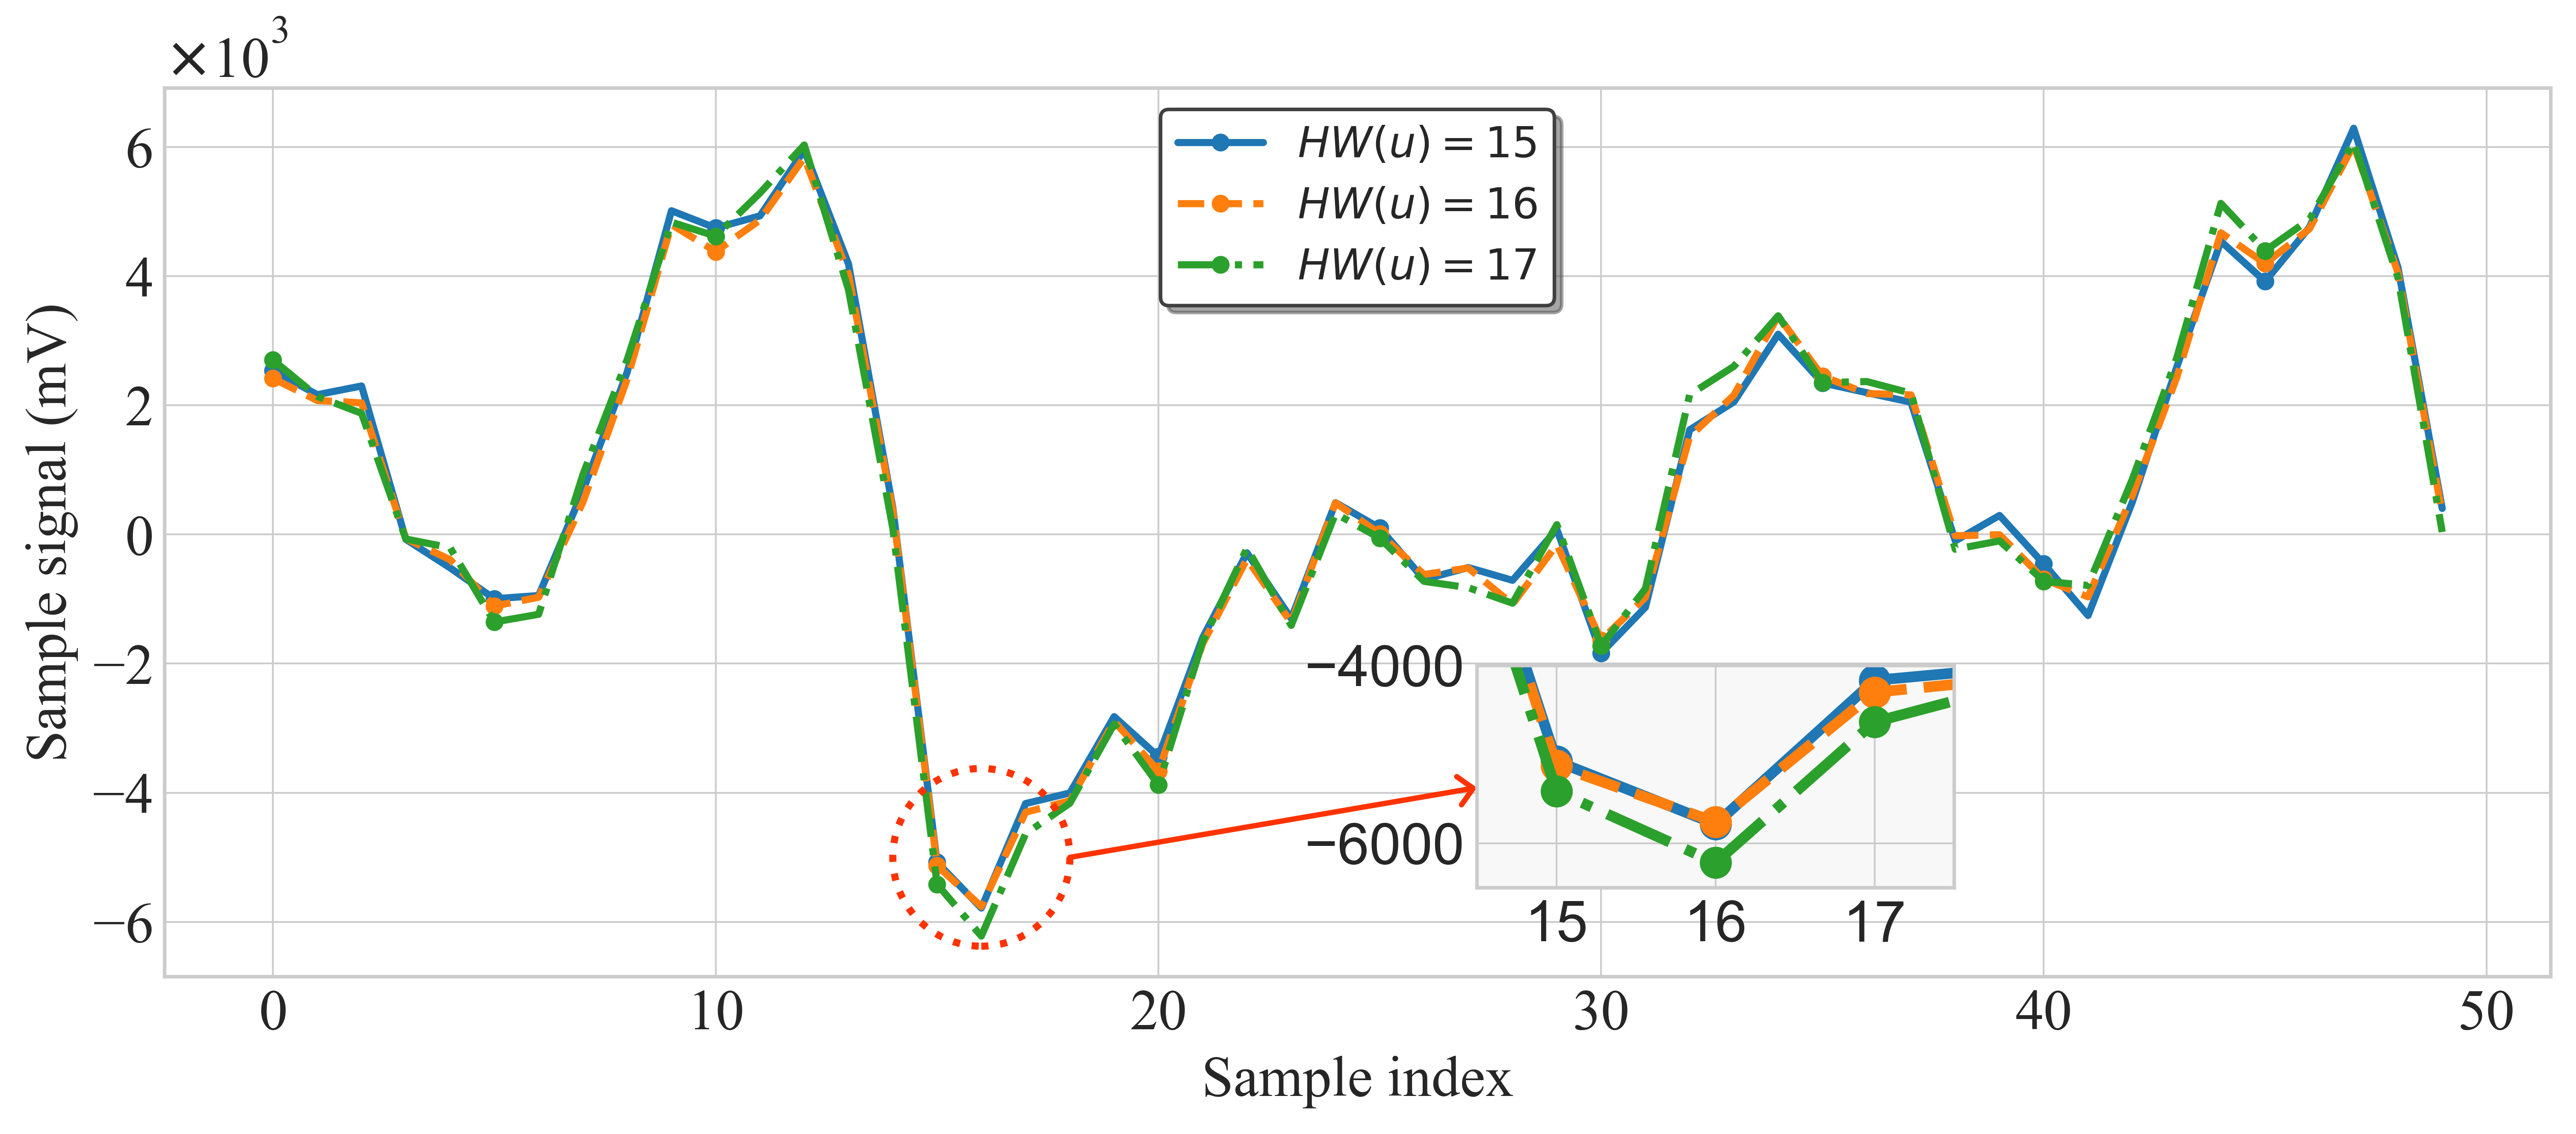

In [129]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, ConnectionPatch

# 主图绘制（保持原始代码逻辑）


plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(12, 4.5), dpi=600)  

# 专业配色方案（CVD友好色系 + 打印友好线型）
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 色盲友好配色
line_styles = ['-', '--', '-.']  # 保证黑白打印时可区分

font_size = 16

x = np.arange(0, 50)  # 假设x轴是采样点索引

for i in range(len(tar)): 
    plt.plot(x, 
            point_mean[i], 
            color=colors[i],
            linestyle=line_styles[i],
            linewidth=2,
            marker='o' if len(tar)<5 else None,  
            markersize=4,
            markevery=5,
            label=rf'$HW(u) = {tar[i]}$')

# ===== 坐标系统优化 =====
ax = plt.gca()
sci_formatter = ticker.ScalarFormatter(useMathText=True)
sci_formatter.set_powerlimits((0, 0))  
ax.yaxis.set_major_formatter(sci_formatter)
ax.yaxis.get_offset_text().set_fontfamily('Times New Roman')

# 坐标轴设置
plt.xlabel('Sample index', fontsize=font_size, fontname='Times New Roman')
plt.ylabel('Sample signal (mV)', fontsize=font_size, fontname='Times New Roman')
plt.xticks(np.arange(0, 51, 10), fontsize=font_size, fontname='Times New Roman')
plt.yticks(fontsize=font_size, fontname='Times New Roman')

# 图例设置
legend = plt.legend(loc='upper center', 
                   frameon=True, 
                   shadow=True,
                   prop={'family':'Times New Roman', 'size':font_size-4},
                   ncol=1 if len(tar)<4 else 2)

# ===== 添加局部放大子图 =====
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


# ===== 创建子图并添加椭圆标记 =====
zoom_start, zoom_end = 15, 17  # 采样点索引范围

# 创建插入子图（调整位置到右上角）
axins = ax.inset_axes([0.55, 0.1, 0.2, 0.25])  # [x, y, width, height] 相对坐标

# 在主图添加红色虚线椭圆（关键参数说明见注释）
focus_ellipse = Ellipse(
    xy=(np.mean([zoom_start, zoom_end]), -5000),  # 中心点坐标
    width=zoom_end - zoom_start+2,       # 椭圆宽度（数据单位）
    height=0.2*(ax.get_ylim()[1]-ax.get_ylim()[0]),  # 椭圆高度（数据单位的30%）
    edgecolor='#FF3300',               # 明红色边框（CVD友好）
    linestyle=':',                     # 点线样式
    linewidth=2,
    facecolor='none',
    zorder=10,
    transform=ax.transData             # 关键！使用数据坐标系
)
ax.add_patch(focus_ellipse)

# ===== 绘制连接线 =====
# 使用ConnectionPatch实现坐标系自动转换
conn = ConnectionPatch(
    xyA=(zoom_end+1, -5000),  # 主图连接点
    xyB=(0, 0.45),                        # 子图右上角（相对坐标）
    coordsA="data", coordsB="axes fraction",  # A为数据坐标，B为子图相对坐标
    axesA=ax, axesB=axins,                   # 指定连接的主图和子图
    color='#FF3300',
    arrowstyle="->,head_width=0.4",          # 箭头样式
    linewidth=1.5
)
ax.add_artist(conn)

# ===== 子图细节设置 =====
# 绘制局部数据（扩展显示范围）
for i in range(len(tar)):
    axins.plot(
        x[zoom_start-2:zoom_end+2],          # 前后多显示2个采样点
        point_mean[i][zoom_start-2:zoom_end+2],
        color=colors[i],
        linestyle=line_styles[i],
        linewidth=3,                         # 加粗曲线
        marker='o',
        markersize=8,
        markevery=1
    )

# 设置子图范围
axins.set_xlim(zoom_start-0.5, zoom_end+0.5)
axins.set_ylim(-6500,-4000)

axins.set_facecolor('#F8F8F8')  # 浅灰色背景提升对比度

plt.savefig('Local power traces.pdf', 
           bbox_inches='tight', 
           pad_inches=0.1,
           dpi=600,
           format='pdf')